# F1 Pit Stop Predictor
This notebook performs EDA, preprocessing, feature engineering, and model selection. Our goal is to predict `PitNextLap`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("dataset.csv")
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

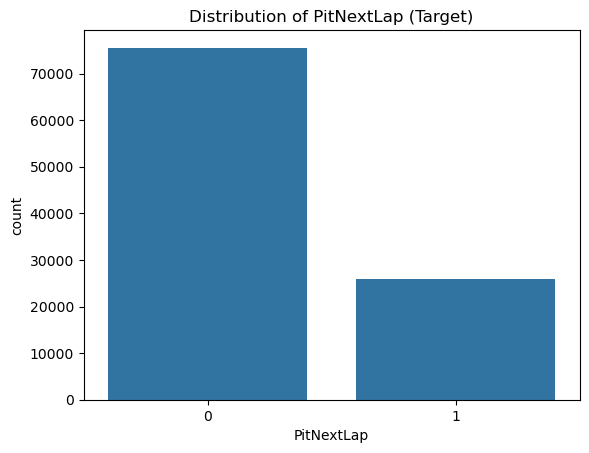

In [3]:
sns.countplot(data=df, x="PitNextLap")
plt.title("Distribution of PitNextLap (Target)")
plt.show()

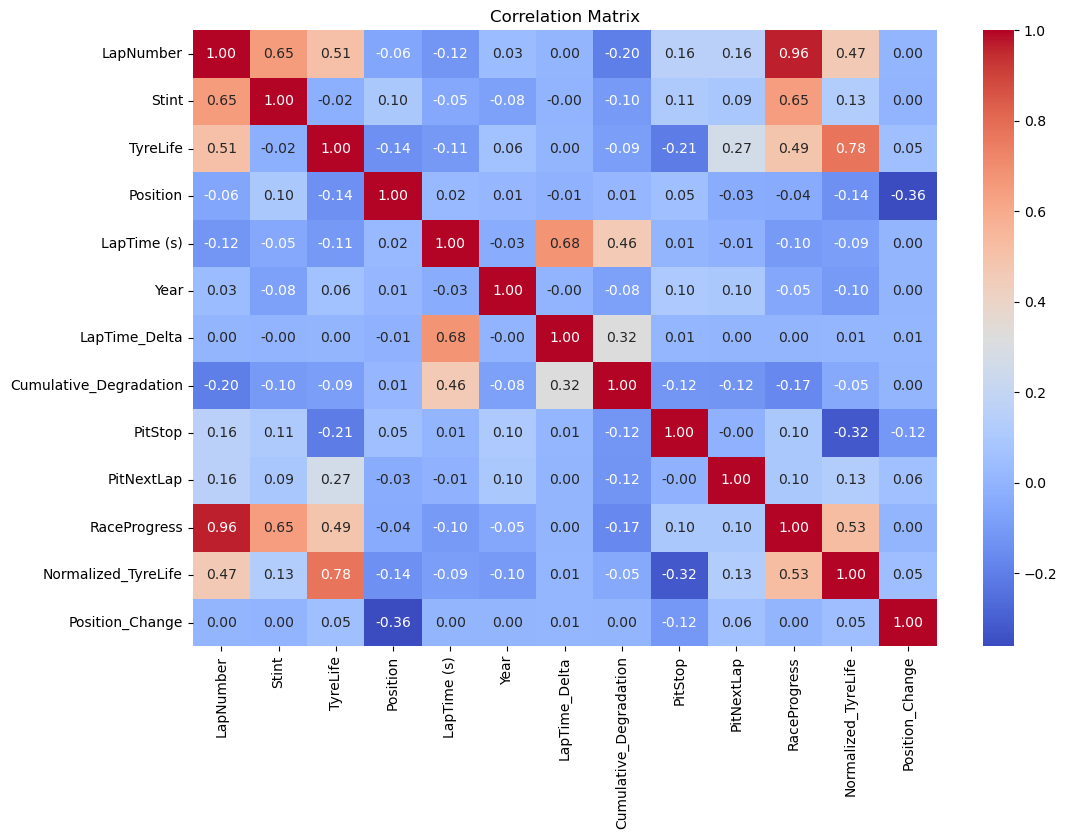

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Data Preprocessing & Cleaning

In [5]:
df["Compound"] = df["Compound"].fillna("Unknown")
# Label Encoding for categorical variables
from sklearn.preprocessing import LabelEncoder

le_driver = LabelEncoder()
df["Driver"] = le_driver.fit_transform(df["Driver"])

le_compound = LabelEncoder()
df["Compound"] = le_compound.fit_transform(df["Compound"])

le_race = LabelEncoder()
df["Race"] = le_race.fit_transform(df["Race"])

df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,0,1,2,1,2.0,17,100.625,0,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,0,2,2,1,3.0,18,93.560,0,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,0,3,2,1,4.0,18,91.768,0,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,0,4,2,1,5.0,18,91.591,0,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,0,5,2,1,6.0,18,91.422,0,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


## Feature Engineering & Selection\nAdding time-series features (Rolling Averages and Gradients).

In [6]:
# Calculate time-series features grouped by Race and Driver
df = df.sort_values(by=["Race", "Driver", "LapNumber"])

df["LapTime_Rolling_3"] = df.groupby(["Race", "Driver"])["LapTime (s)"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
df["LapTime_Gradient"] = df.groupby(["Race", "Driver"])["LapTime (s)"].diff().fillna(0)

# Drop non-predictive columns
cols_to_drop = ["PitStop", "Year"]
df = df.drop(columns=cols_to_drop)

X = df.drop(columns=["PitNextLap"])
y = df["PitNextLap"]

print("Features:", X.columns.tolist())

Features: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change', 'LapTime_Rolling_3', 'LapTime_Gradient']


## Train-Test Split\nUsing `GroupShuffleSplit` on the `Race` column to prevent sequential data leakage.

In [7]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=X["Race"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in train:", np.bincount(y_train))

Train shape: (79283, 15)
Test shape: (22088, 15)
Class distribution in train: [59837 19446]


## Model Selection
Using F1-Score to evaluate different models due to class imbalance.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

# Calculate scale_pos_weight for XGBoost to handle class imbalance
scale_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
}

best_model_name = ""
best_f1 = 0
best_model = None

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} F1 Score: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = model

print(f"\nBest Model: {best_model_name} with F1 Score: {best_f1:.4f}")

Calculated scale_pos_weight: 3.08
Training Logistic Regression...
Logistic Regression F1 Score: 0.2685
Training Random Forest...
Random Forest F1 Score: 0.6045
Training XGBoost...
XGBoost F1 Score: 0.6713

Best Model: XGBoost with F1 Score: 0.6713


## Hyperparameter Tuning
Tuning the best performing model. Constraints applied to prevent overfitting.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

if best_model_name == "XGBoost":
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
elif best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_leaf': [2, 5, 10]
    }
else:
    param_grid = {'C': [0.1, 1, 10]}

print(f"Tuning {best_model_name}...")
search = RandomizedSearchCV(best_model, param_distributions=param_grid, n_iter=5, scoring='f1', cv=3, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
tuned_model = search.best_estimator_

Tuning XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}


## Model Testing and Validation

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     15705
           1       0.61      0.85      0.71      6383

    accuracy                           0.80     22088
   macro avg       0.77      0.82      0.78     22088
weighted avg       0.84      0.80      0.81     22088



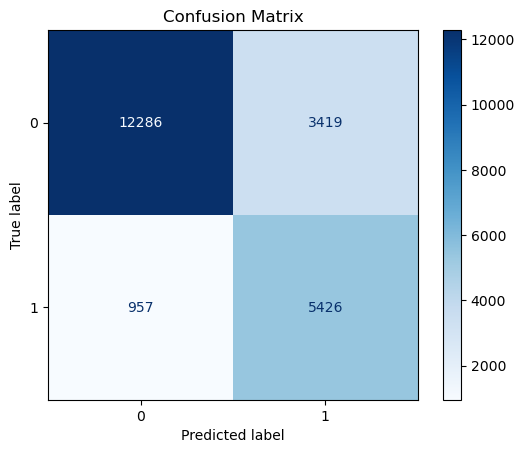

Model saved to best_f1_pit_stop_model.pkl


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate tuned model
y_pred_tuned = tuned_model.predict(X_test)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_tuned))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tuned_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Save the final model
import joblib
joblib.dump(tuned_model, 'best_f1_pit_stop_model.pkl')
print("Model saved to best_f1_pit_stop_model.pkl")